# DeepEval Commentary Analysis

Анализ качества шахматных комментариев по метрикам deepeval.  
Поддерживает сравнение нескольких файлов (конфигураций).

In [2895]:
from __future__ import annotations
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

RESULTS_DIR = Path("results")

## 1. Выбор файлов для анализа

Укажи файлы и человекочитаемые метки конфигураций в `FILES`.  
Можно один файл или несколько для сравнения.

In [ ]:
# ── Настройка ────────────────────────────────────────────────────────────────
# Ключ = метка конфигурации (появится на графиках)
# Значение = путь к .jsonl файлу
FILES: dict[str, str] = {
    "gemma_raw_alex": "results/deepeval_20260521_234440.jsonl",
    #"baseline": "results/deepeval_config_full_think_off.jsonl",
    "gemaa_theory": "results/deepeval_20260522_022159.jsonl",
    "gemma_alex": "results/deepeval_20260522_012214.jsonl",
    "gemma_min": "results/deepeval_20260522_005724.jsonl",
    "sonnet": "results/deepeval_20260522_000703.jsonl",
    #"gemma_v3": "results/deepeval_20260521_225540.jsonl",
    #"gemma_system_instruct_fix": "results/deepeval_20260521_223304.jsonl",
    # "gemma_baseline": "results/deepeval_20260521_222247.jsonl",
    # "qwen_full_new_metrics": "results/deepeval_20260521_215126.jsonl",
    # "qwen_full": "results/deepeval_20260521_213504.jsonl",
    "haiku_new_metrcs": "results/deepeval_20260521_204437.jsonl",
    # "haiku": "results/deepeval_20260521_200926.jsonl",
    # "alexander_off": "results/deepeval_20260521_140609.jsonl",
    # "think_off_makogonov_off_tresholds_strict": "results/deepeval_20260521_133107.jsonl",
    # "think_on": "results/deepeval_20260521_125422.jsonl",
    
}

# Фильтр по game_id (None = все игры)
GAME_FILTER: str | None = None  # например: "eval_trace_1779275077"
# ─────────────────────────────────────────────────────────────────────────────

In [2897]:
def load_jsonl(path: str | Path) -> list[dict]:
    records = []
    with open(path, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return records


def build_df(records: list[dict], label: str) -> pd.DataFrame:
    rows = []
    for r in records:
        base = {
            "run": label,
            "trace_id": r["trace_id"],
            "game_id": r["game_id"],
            "move_number": r["move_number"],
            "san": r["san"],
            "color": r.get("color", "unknown"),
            "quality": r.get("quality", "unknown"),
            "overall_pass": r["overall_pass"],
            "commentary": r.get("commentary", ""),
        }
        for m in r.get("metrics", []):
            # strip " [GEval]" suffix for short names
            name = m["name"].replace(" [GEval]", "").replace(" ", "_")
            base[f"score_{name}"] = m["score"]
            base[f"pass_{name}"] = m["success"]
            base[f"reason_{name}"] = m.get("reason", "")
        rows.append(base)
    return pd.DataFrame(rows)


dfs: dict[str, pd.DataFrame] = {}
for label, path in FILES.items():
    records = load_jsonl(path)
    df = build_df(records, label)
    if GAME_FILTER:
        df = df[df["game_id"] == GAME_FILTER]
    dfs[label] = df
    print(f"{label}: {len(df)} записей, игры: {df['game_id'].nunique()}")

all_df = pd.concat(dfs.values(), ignore_index=True)
SCORE_COLS = [c for c in all_df.columns if c.startswith("score_")]
METRIC_NAMES = [c.replace("score_", "") for c in SCORE_COLS]
print(f"\nМетрики: {METRIC_NAMES}")

gemma_raw_alex: 52 записей, игры: 1
gemma_alex: 35 записей, игры: 1
gemma_min: 52 записей, игры: 1
sonnet: 51 записей, игры: 1
haiku_new_metrcs: 52 записей, игры: 1

Метрики: ['Accuracy', 'ConceptualDepth', 'InputCoverage', 'HallucinationControl']


## 2. Сводная таблица по конфигурациям

In [2898]:
summary_rows = []
for label, df in dfs.items():
    row = {"run": label, "traces": len(df), "pass_rate": df["overall_pass"].mean()}
    for col in SCORE_COLS:
        if col in df.columns:
            row[col.replace("score_", "")] = df[col].mean()
    summary_rows.append(row)

summary = pd.DataFrame(summary_rows).set_index("run")
metric_cols = [c for c in summary.columns if c not in ("traces", "pass_rate")]

display(
    summary.style
    .format({"pass_rate": "{:.1%}", **{c: "{:.3f}" for c in metric_cols}})
    .background_gradient(subset=metric_cols, cmap="RdYlGn", vmin=0, vmax=1)
    .background_gradient(subset=["pass_rate"], cmap="RdYlGn", vmin=0, vmax=1)
    .set_caption("Средние оценки по метрикам (выше = лучше)")
)

,traces,pass_rate,Accuracy,ConceptualDepth,InputCoverage,HallucinationControl
run,,,,,,
gemma_raw_alex,52,0.0%,0.029,0.044,0.040,0.025
gemma_alex,35,0.0%,0.186,0.251,0.257,0.194
gemma_min,52,1.9%,0.204,0.283,0.287,0.190
sonnet,51,25.5%,0.394,0.641,0.633,0.578
haiku_new_metrcs,52,7.7%,0.365,0.417,0.483,0.513


## 3. Сравнение метрик по конфигурациям (radar + bar)

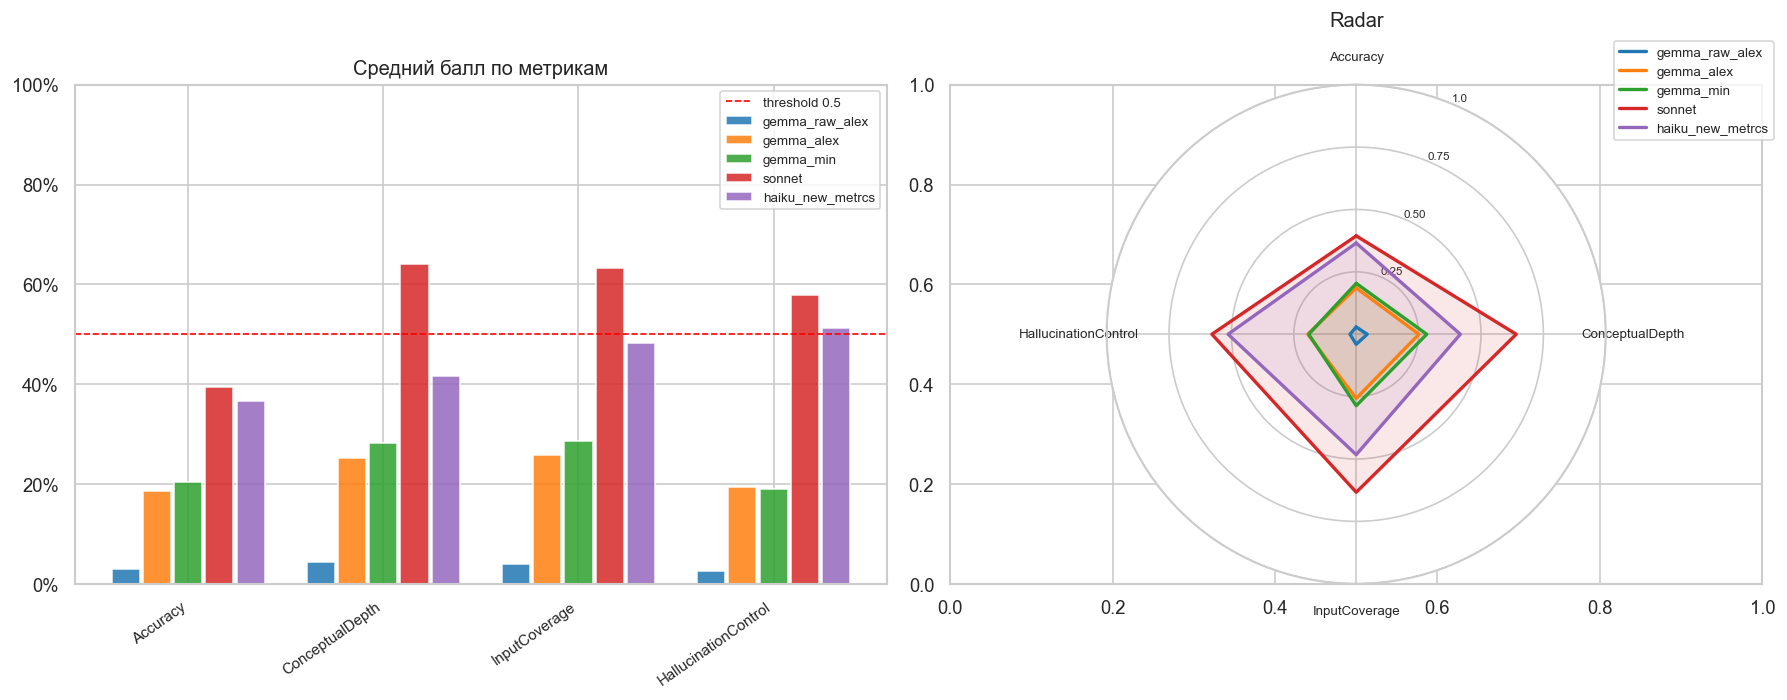

In [2899]:
runs = list(dfs.keys())
colors = sns.color_palette("tab10", len(runs))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Bar chart ---
ax = axes[0]
x = np.arange(len(METRIC_NAMES))
width = 0.8 / max(len(runs), 1)
for i, (label, df) in enumerate(dfs.items()):
    means = [df[f"score_{m}"].mean() if f"score_{m}" in df.columns else 0 for m in METRIC_NAMES]
    ax.bar(x + i * width - width * (len(runs) - 1) / 2, means,
           width=width * 0.9, label=label, color=colors[i], alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(METRIC_NAMES, rotation=35, ha="right", fontsize=9)
ax.set_ylim(0, 1)
ax.axhline(0.5, color="red", ls="--", lw=1, label="threshold 0.5")
ax.set_title("Средний балл по метрикам")
ax.legend(fontsize=8)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

# --- Radar chart ---
ax2 = axes[1]
N = len(METRIC_NAMES)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

ax2 = plt.subplot(122, polar=True)
ax2.set_theta_offset(np.pi / 2)
ax2.set_theta_direction(-1)
ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(METRIC_NAMES, size=8)
ax2.set_ylim(0, 1)
ax2.set_yticks([0.25, 0.5, 0.75, 1.0])
ax2.set_yticklabels(["0.25", "0.50", "0.75", "1.0"], size=7)

for i, (label, df) in enumerate(dfs.items()):
    values = [df[f"score_{m}"].mean() if f"score_{m}" in df.columns else 0 for m in METRIC_NAMES]
    values += values[:1]
    ax2.plot(angles, values, linewidth=2, color=colors[i], label=label)
    ax2.fill(angles, values, alpha=0.1, color=colors[i])
ax2.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1), fontsize=8)
ax2.set_title("Radar", pad=15)

plt.tight_layout()
plt.show()

## 4. Распределение оценок по метрикам (box plot)

/var/folders/v7/jd9nwf555hqg15pmncp612mc0000gn/T/ipykernel_79747/199083934.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")


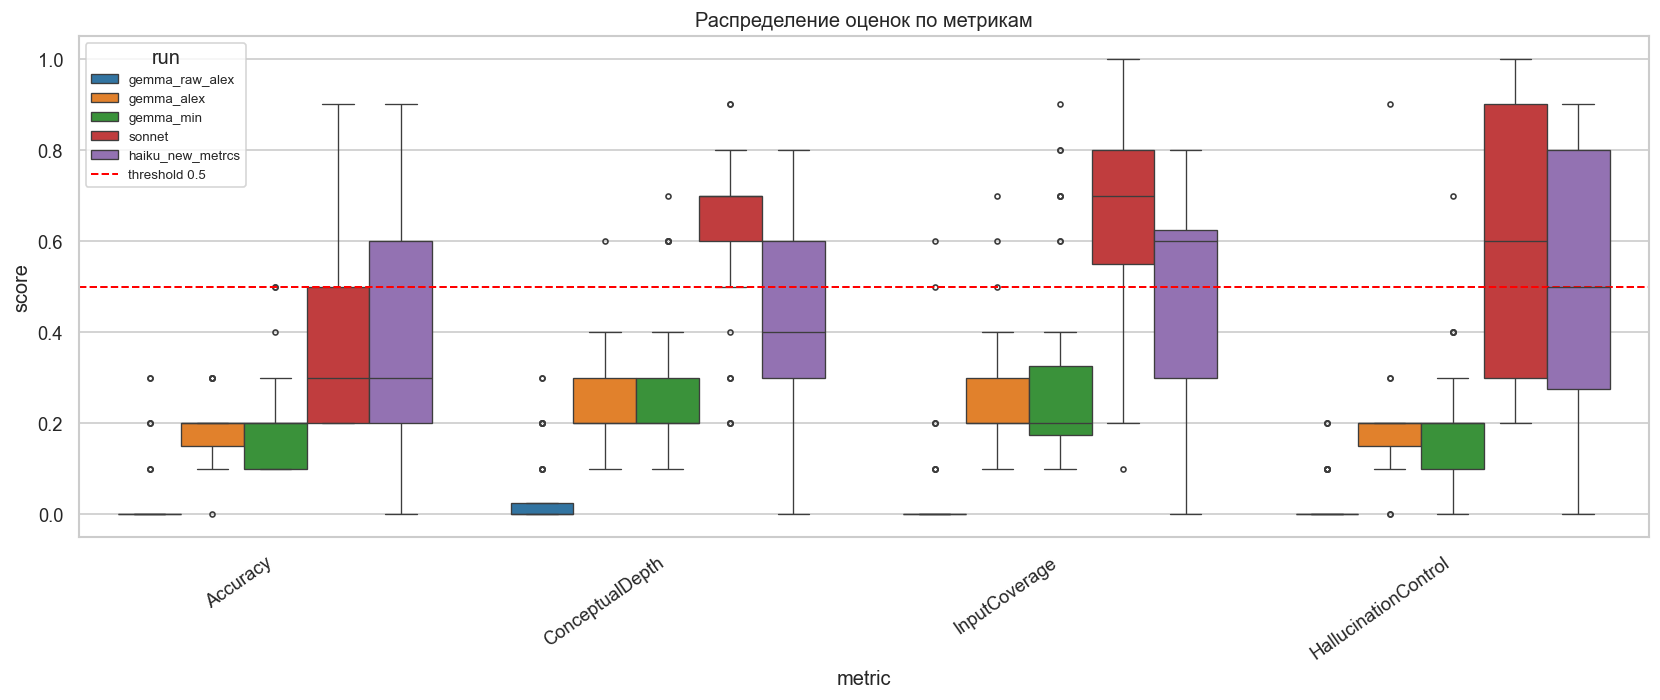

In [2900]:
rows_long = []
for label, df in dfs.items():
    for m in METRIC_NAMES:
        col = f"score_{m}"
        if col in df.columns:
            for v in df[col].dropna():
                rows_long.append({"run": label, "metric": m, "score": v})
long_df = pd.DataFrame(rows_long)

fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(
    data=long_df, x="metric", y="score", hue="run",
    palette="tab10", linewidth=0.8, fliersize=3, ax=ax
)
ax.axhline(0.5, color="red", ls="--", lw=1.2, label="threshold 0.5")
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")
ax.set_ylim(-0.05, 1.05)
ax.set_title("Распределение оценок по метрикам")
ax.legend(title="run", fontsize=8)
plt.tight_layout()
plt.show()

## 5. Pass Rate по качеству хода (quality) и цвету

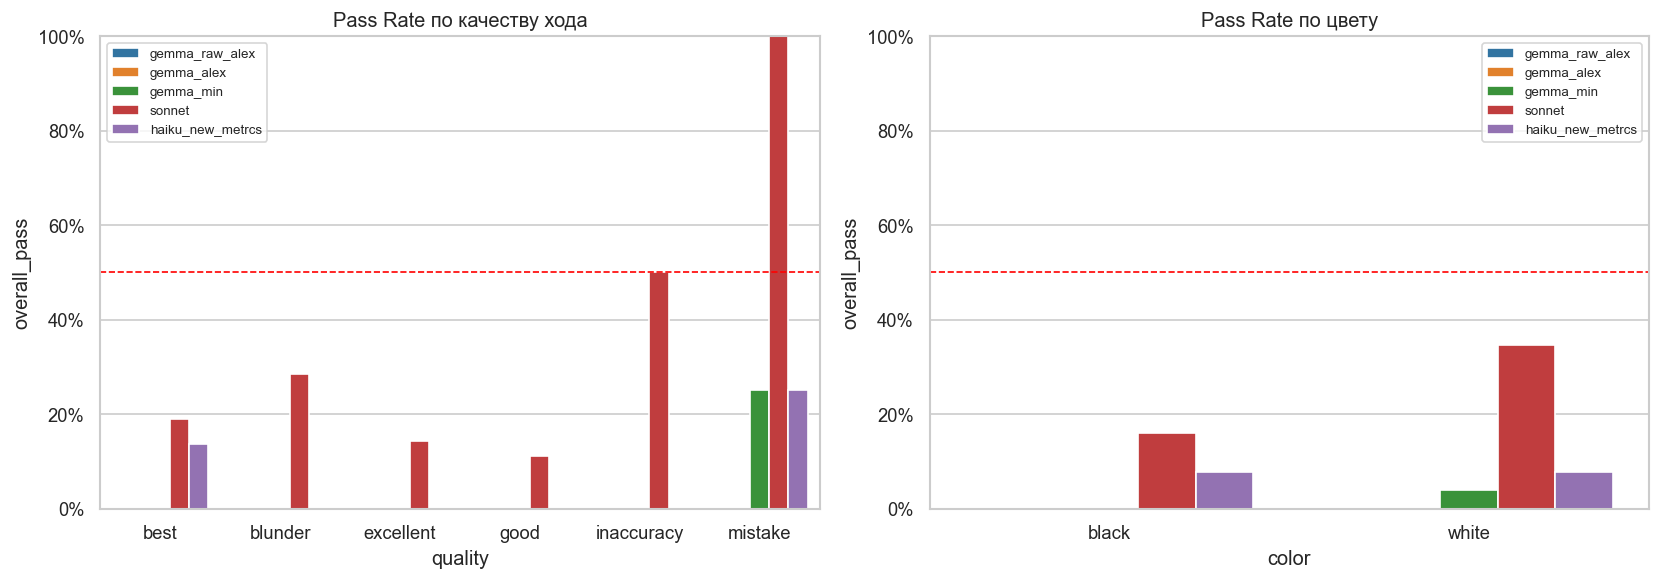

In [2901]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, group_col, title in [
    (axes[0], "quality", "Pass Rate по качеству хода"),
    (axes[1], "color",   "Pass Rate по цвету"),
]:
    rows = []
    for label, df in dfs.items():
        gr = df.groupby(group_col)["overall_pass"].mean().reset_index()
        gr["run"] = label
        rows.append(gr)
    g = pd.concat(rows)
    sns.barplot(data=g, x=group_col, y="overall_pass", hue="run",
                palette="tab10", ax=ax)
    ax.set_ylim(0, 1)
    ax.axhline(0.5, color="red", ls="--", lw=1)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 6. Динамика оценок по номерам ходов

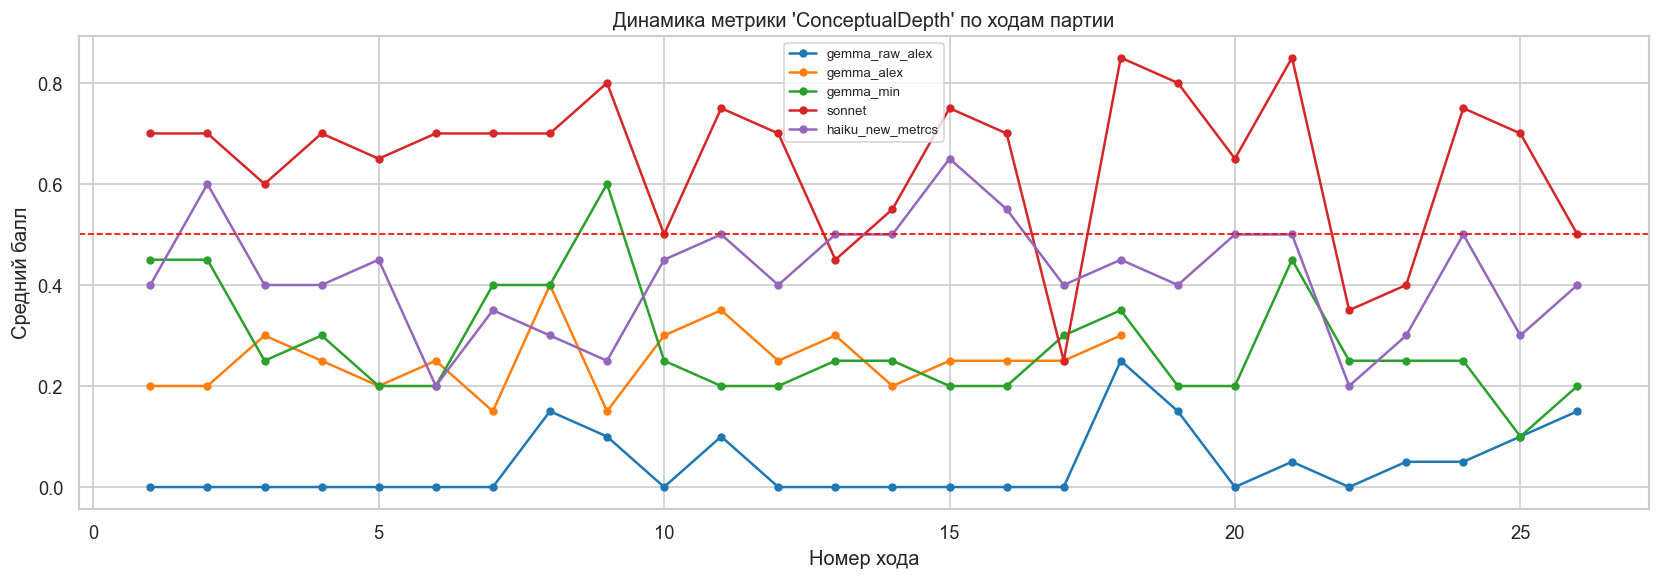

In [2902]:
# Выбери метрику или 'overall_pass' для отображения
METRIC_FOR_TREND = METRIC_NAMES[1] if METRIC_NAMES else None

if METRIC_FOR_TREND:
    col = f"score_{METRIC_FOR_TREND}"
    fig, ax = plt.subplots(figsize=(14, 5))
    for i, (label, df) in enumerate(dfs.items()):
        if col not in df.columns:
            continue
        trend = df.groupby("move_number")[col].mean()
        ax.plot(trend.index, trend.values, marker="o", ms=4,
                label=label, color=colors[i])
    ax.axhline(0.5, color="red", ls="--", lw=1)
    ax.set_xlabel("Номер хода")
    ax.set_ylabel("Средний балл")
    ax.set_title(f"Динамика метрики '{METRIC_FOR_TREND}' по ходам партии")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print("Нет метрик для отображения.")

## 7. Тепловая карта средних оценок (конфигурация × метрика)

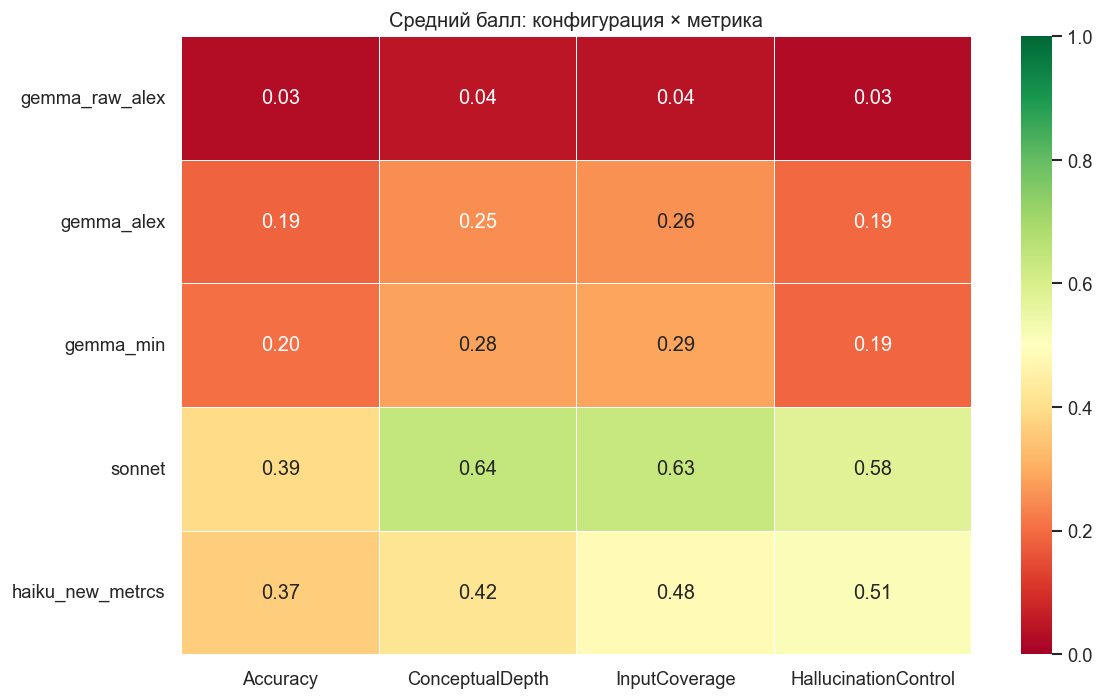

In [2903]:
heat_data = {}
for label, df in dfs.items():
    heat_data[label] = {m: df[f"score_{m}"].mean() if f"score_{m}" in df.columns else np.nan
                        for m in METRIC_NAMES}

heat_df = pd.DataFrame(heat_data).T  # rows = runs, cols = metrics

fig, ax = plt.subplots(figsize=(max(10, len(METRIC_NAMES) * 1.3), max(3, len(dfs) * 1.2)))
sns.heatmap(
    heat_df, annot=True, fmt=".2f", cmap="RdYlGn",
    vmin=0, vmax=1, linewidths=0.5, ax=ax
)
ax.set_title("Средний балл: конфигурация × метрика")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 8. Худшие комментарии (для отладки)

In [2904]:
# Показать N худших комментариев по avg score (для выбранного run'а)
TARGET_RUN = list(dfs.keys())[1]
TOP_N = 10

df = dfs[TARGET_RUN].copy()
df["avg_score"] = df[SCORE_COLS].mean(axis=1)
worst = df.nsmallest(TOP_N, "avg_score")[
    ["trace_id", "move_number", "san", "color", "quality", "avg_score", "overall_pass"] + SCORE_COLS
]

display(
    worst.style
    .format({"avg_score": "{:.3f}", **{c: "{:.2f}" for c in SCORE_COLS}})
    .background_gradient(subset=["avg_score"] + SCORE_COLS, cmap="RdYlGn", vmin=0, vmax=1)
    .set_caption(f"Топ-{TOP_N} худших комментариев ({TARGET_RUN})")
)

,trace_id,move_number,san,color,quality,avg_score,overall_pass,score_Accuracy,score_ConceptualDepth,score_InputCoverage,score_HallucinationControl
12,eval_trace_alexander_off__m7_Ne5_white_inaccuracy,7,Ne5,white,inaccuracy,0.050,False,0.00,0.10,0.10,0.00
26,eval_trace_alexander_off__m14_Nc3_white_best,14,Nc3,white,best,0.100,False,0.10,0.10,0.20,0.00
7,eval_trace_alexander_off__m4_Nc6_black_excellent,4,Nc6,black,excellent,0.125,False,0.10,0.20,0.10,0.10
17,eval_trace_alexander_off__m9_Nf2+_black_inaccuracy,9,Nf2+,black,inaccuracy,0.125,False,0.10,0.10,0.20,0.10
29,eval_trace_alexander_off__m15_Nb4_black_blunder,15,Nb4,black,blunder,0.125,False,0.10,0.20,0.10,0.10
3,eval_trace_alexander_off__m2_Nf6_black_best,2,Nf6,black,best,0.150,False,0.10,0.20,0.20,0.10
24,eval_trace_alexander_off__m13_cxd5_white_excellent,13,cxd5,white,excellent,0.150,False,0.20,0.20,0.10,0.10
33,eval_trace_alexander_off__m17_Qe3_black_best,17,Qe3,black,best,0.150,False,0.10,0.20,0.20,0.10
1,eval_trace_alexander_off__m1_f5_black_good,1,f5,black,good,0.150,False,0.10,0.20,0.10,0.20
23,eval_trace_alexander_off__m12_O-O_black_blunder,12,O-O,black,blunder,0.175,False,0.20,0.20,0.20,0.10


In [2905]:
best = df.nlargest(TOP_N, "avg_score")[
    ["trace_id", "move_number", "san", "color", "quality", "avg_score", "overall_pass"] + SCORE_COLS
]

display(
    best.style
    .format({"avg_score": "{:.3f}", **{c: "{:.2f}" for c in SCORE_COLS}})
    .background_gradient(subset=["avg_score"] + SCORE_COLS, cmap="RdYlGn", vmin=0, vmax=1)
    .set_caption(f"Топ-{TOP_N} лучших комментариев ({TARGET_RUN})")
)

,trace_id,move_number,san,color,quality,avg_score,overall_pass,score_Accuracy,score_ConceptualDepth,score_InputCoverage,score_HallucinationControl
11,eval_trace_alexander_off__m6_e6_black_best,6,e6,black,best,0.500,False,0.30,0.30,0.50,0.90
14,eval_trace_alexander_off__m8_f3_white_best,8,f3,white,best,0.450,False,0.30,0.60,0.70,0.20
21,eval_trace_alexander_off__m11_Qxd4+_black_best,11,Qxd4+,black,best,0.350,False,0.30,0.30,0.60,0.20
6,eval_trace_alexander_off__m4_Bg5_white_excellent,4,Bg5,white,excellent,0.300,False,0.20,0.30,0.40,0.30
25,eval_trace_alexander_off__m13_exd5_black_best,13,exd5,black,best,0.300,False,0.20,0.40,0.40,0.20
9,eval_trace_alexander_off__m5_Ne4_black_excellent,5,Ne4,black,excellent,0.275,False,0.30,0.20,0.40,0.20
18,eval_trace_alexander_off__m10_Bxf2_white_good,10,Bxf2,white,good,0.275,False,0.30,0.40,0.20,0.20
4,eval_trace_alexander_off__m3_c3_white_excellent,3,c3,white,excellent,0.250,False,0.20,0.30,0.30,0.20
8,eval_trace_alexander_off__m5_Qb3_white_excellent,5,Qb3,white,excellent,0.250,False,0.20,0.20,0.40,0.20
20,eval_trace_alexander_off__m11_c4_white_blunder,11,c4,white,blunder,0.250,False,0.20,0.40,0.20,0.20


## 9. Детальный просмотр комментария

In [2906]:
# Вставь trace_id для подробного разбора
INSPECT_TRACE = worst.iloc[0]["trace_id"] if not worst.empty else ""
INSPECT_RUN   = TARGET_RUN

row = dfs[INSPECT_RUN][dfs[INSPECT_RUN]["trace_id"] == INSPECT_TRACE]
if row.empty:
    print(f"Trace '{INSPECT_TRACE}' не найден в {INSPECT_RUN}")
else:
    row = row.iloc[0]
    print(f"=== {INSPECT_TRACE} ===")
    print(f"Move #{row['move_number']} {row['san']} ({row['color']}, {row['quality']})")
    print(f"Overall pass: {row['overall_pass']}\n")
    print("─── Commentary ───")
    print(row["commentary"])
    print()
    for m in METRIC_NAMES:
        score = row.get(f"score_{m}", "n/a")
        passed = row.get(f"pass_{m}", "?")
        reason = row.get(f"reason_{m}", "")
        status = "✅" if passed else "❌"
        print(f"{status} {m}: {score:.2f}" if isinstance(score, float) else f"{status} {m}: {score}")
        if reason:
            # wrap at ~100 chars
            import textwrap
            for line in textwrap.wrap(reason, 100):
                print(f"    {line}")
        print()

=== eval_trace_alexander_off__m7_Ne5_white_inaccuracy ===
Move #7 Ne5 (white, inaccuracy)
Overall pass: False

─── Commentary ───
1. Played: White's knight moves to e5 (inaccuracy) — significant loss for Black — position is slightly worse.  
2. Engine: White's pawn moves to g3 would have been stronger — after pawn to e5, then pawn to f4.  
3. Opening: Dutch Defense. Background: Unlike the opening, which often follows established formulas, or the endgame, which can be defined by known structures, the middlegame is a vast ocean where ideas often intertwine.

❌ Accuracy: 0.00
    The actual output merely restates the input verbatim without addressing the task. The task
    explicitly asks 'Why did the engine prefer a different move, and what would it have accomplished?'
    with specific focus on explaining the engine's preference for g3 over the knight to e5. The output
    provides no analysis, reasoning, or explanation—it simply repeats the given context. Additionally,
    the output v

## 10. Дельта между конфигурациями (попарное сравнение)

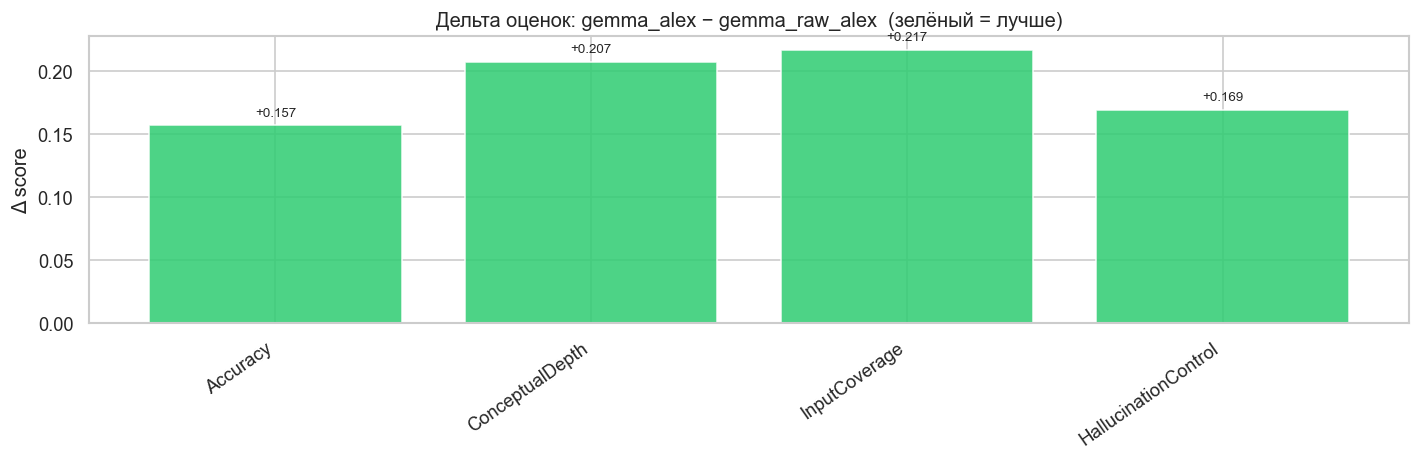

Pass rate: gemma_raw_alex=0.0%  gemma_alex=0.0%  Δ=+0.0%


In [2907]:
if len(dfs) >= 2:
    run_names = list(dfs.keys())
    BASE_RUN = run_names[0]
    CMP_RUN  = run_names[1]

    base_means = {m: dfs[BASE_RUN][f"score_{m}"].mean() for m in METRIC_NAMES if f"score_{m}" in dfs[BASE_RUN].columns}
    cmp_means  = {m: dfs[CMP_RUN][f"score_{m}"].mean()  for m in METRIC_NAMES if f"score_{m}" in dfs[CMP_RUN].columns}

    deltas = {m: cmp_means.get(m, 0) - base_means.get(m, 0) for m in METRIC_NAMES}

    fig, ax = plt.subplots(figsize=(12, 4))
    x = np.arange(len(METRIC_NAMES))
    bar_colors = ["#2ecc71" if v >= 0 else "#e74c3c" for v in deltas.values()]
    ax.bar(x, list(deltas.values()), color=bar_colors, alpha=0.85)
    ax.axhline(0, color="black", lw=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(METRIC_NAMES, rotation=35, ha="right")
    ax.set_title(f"Дельта оценок: {CMP_RUN} − {BASE_RUN}  (зелёный = лучше)")
    ax.set_ylabel("Δ score")
    for xi, v in zip(x, deltas.values()):
        ax.text(xi, v + (0.005 if v >= 0 else -0.012), f"{v:+.3f}",
                ha="center", va="bottom" if v >= 0 else "top", fontsize=8)
    plt.tight_layout()
    plt.show()

    delta_pass = dfs[CMP_RUN]["overall_pass"].mean() - dfs[BASE_RUN]["overall_pass"].mean()
    print(f"Pass rate: {BASE_RUN}={dfs[BASE_RUN]['overall_pass'].mean():.1%}  "
          f"{CMP_RUN}={dfs[CMP_RUN]['overall_pass'].mean():.1%}  "
          f"Δ={delta_pass:+.1%}")
else:
    print("Добавь второй файл в FILES для сравнения.")

## 11. Сравнение по общим trace_id (только общие ходы)

In [2908]:
if len(dfs) >= 2:
    run_names = list(dfs.keys())
    BASE_RUN, CMP_RUN = run_names[0], run_names[1]
    common_ids = set(dfs[BASE_RUN]["trace_id"]) & set(dfs[CMP_RUN]["trace_id"])
    print(f"Общих trace_id: {len(common_ids)}")

    if common_ids:
        shared_rows = []
        for tid in sorted(common_ids):
            r_base = dfs[BASE_RUN][dfs[BASE_RUN]["trace_id"] == tid].iloc[0]
            r_cmp  = dfs[CMP_RUN][dfs[CMP_RUN]["trace_id"] == tid].iloc[0]
            row = {"trace_id": tid, "move_number": r_base["move_number"],
                   "san": r_base["san"], "quality": r_base["quality"]}
            for m in METRIC_NAMES:
                c = f"score_{m}"
                v_base = r_base.get(c, np.nan)
                v_cmp  = r_cmp.get(c, np.nan)
                row[f"{m}_base"] = v_base
                row[f"{m}_cmp"]  = v_cmp
                row[f"{m}_delta"] = v_cmp - v_base
            shared_rows.append(row)

        shared_df = pd.DataFrame(shared_rows).sort_values("move_number")
        delta_cols = [f"{m}_delta" for m in METRIC_NAMES]

        display(
            shared_df[["trace_id", "move_number", "san", "quality"] + delta_cols]
            .style
            .format({c: "{:+.2f}" for c in delta_cols})
            .background_gradient(subset=delta_cols, cmap="RdYlGn", vmin=-0.5, vmax=0.5)
            .set_caption(f"Δ score по общим ходам: {CMP_RUN} − {BASE_RUN}")
        )
else:
    print("Нужно минимум 2 конфигурации.")

Общих trace_id: 0
